# Emotion-Aware Robot Behavior Engine
**Walkthrough & Implementation**

This notebook is a clean walkthrough of an end-to-end emotion-aware AI pipeline. It takes raw speech audio, transcribes it, predicts the emotion, generates an empathetic response using an LLM, and synthesizes a voice response.


### Step 1: Environment Setup
First, we mount Google Drive to access our dataset and API keys, and install all required libraries.


In [41]:
# =========================================================================
# 🚀 RUNNING ON GOOGLE COLAB
# =========================================================================
# To run this pipeline quickly, it is highly recommended to use Google Colab's free GPU.
# 1. Upload the 'Oulu Project' folder to the main directory of your Google Drive.
# 2. Run this cell to connect your Google Drive to Colab.

from google.colab import drive
drive.mount('/content/drive')

# Install all required libraries
!pip install -q pyarrow fastparquet openai-whisper evaluate transformers datasets accelerate soundfile librosa groq gTTS


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Step 2: Data Loading
We load the raw IEMOCAP dataset containing our audio recordings and text transcripts from parquet files.


In [42]:
import os
import pandas as pd
from tqdm.auto import tqdm

folder_path = '/content/drive/MyDrive/Oulu Project/iemocap_parquet_dataset'

# Find all parquet files
parquet_files = [f for f in os.listdir(folder_path) if f.endswith('.parquet')]
print("Parquet files found:\n", parquet_files)

# Read and concatenate
dfs = []
for file in parquet_files:
    print(f"Reading {file} ...")
    dfs.append(pd.read_parquet(os.path.join(folder_path, file)))

IEMOCAP_Dataset = pd.concat(dfs, ignore_index=True)
print("\nAll files loaded successfully!")
print("Combined DataFrame Shape:", IEMOCAP_Dataset.shape)


Parquet files found:
 ['train-00000-of-00003.parquet', 'train-00001-of-00003.parquet', 'train-00002-of-00003.parquet']
Reading train-00000-of-00003.parquet ...
Reading train-00001-of-00003.parquet ...
Reading train-00002-of-00003.parquet ...

All files loaded successfully!
Combined DataFrame Shape: (10039, 22)


### Step 3: Unified Data Preprocessing
To prepare the data for training and evaluation, we will perform all our data cleaning in one unified step:
1. Remove minority emotion classes (`disgust` and `other`).
2. Map the 4 target emotions (`angry`, `happy`, `neutral`, `sad`) to numerical labels.
3. Extract the recording session number to separate train/test splits (Session 1-4 for train, Session 5 for test).


In [45]:
import numpy as np

# 1. Drop unused minority classes
IEMOCAP_Dataset = IEMOCAP_Dataset[~IEMOCAP_Dataset["major_emotion"].isin(["disgust", "other"])].copy()

# 2. Map emotions to numerical labels for the model
LABELS = ["angry", "happy", "neutral", "sad"]
LABEL2ID = {label: i for i, label in enumerate(LABELS)}
ID2LABEL = {i: label for label, i in LABEL2ID.items()}

# Filter only the 4 main emotions
four_class_df = IEMOCAP_Dataset[IEMOCAP_Dataset["major_emotion"].isin(LABELS)].copy()
four_class_df["label"] = four_class_df["major_emotion"].map(LABEL2ID)

# 3. Extract Session number for Train/Test splitting
four_class_df["session"] = four_class_df["file"].str.extract(r"(Ses\d{2})")[0]

# Split the dataset
train_df = four_class_df[four_class_df["session"] != "Ses05"].copy()
test_df = four_class_df[four_class_df["session"] == "Ses05"].copy()

print(f"Total records remaining: {len(four_class_df)}")
print(f"Training records (Ses 1-4): {len(train_df)}")
print(f"Testing records (Ses 5): {len(test_df)}")


Total records remaining: 4901
Training records (Ses 1-4): 3853
Testing records (Ses 5): 1048


### Step 4: Baseline Machine Learning Model (SVM)
Before moving to advanced deep learning, we established a baseline by training a Support Vector Machine (SVM) on 84 acoustic features (MFCCs, Pitch, Zero-Crossing Rate, RMS).
> [!NOTE]
> Below is the reference code containing the math used to extract these features directly from the raw audio waveforms. Because this extraction takes 10-15 minutes, the active code cell below this block loads the pre-computed features from a CSV to instantly train and evaluate the baseline model!


```python
# =================================================================
# [REFERENCE CODE] ACOUSTIC FEATURE EXTRACTION FROM SCRATCH
# =================================================================
import librosa
import soundfile as sf
from io import BytesIO
import numpy as np
def extract_features(audio_dict, n_mfcc=40):
    try:
        # Load raw audio bytes
        y, sr = sf.read(BytesIO(audio_dict["bytes"]), dtype="float32")
        
        # Convert to mono and resample to 16kHz
        if len(y.shape) > 1: y = y.mean(axis=1)
        if sr != 16000: y = librosa.resample(y, orig_sr=sr, target_sr=16000)
        
        # Extract features
        mfcc = librosa.feature.mfcc(y=y, sr=16000, n_mfcc=n_mfcc)
        pitch = librosa.yin(y, fmin=50, fmax=400, sr=16000)
        rms = librosa.feature.rms(y=y)
        zcr = librosa.feature.zero_crossing_rate(y)
        centroid = librosa.feature.spectral_centroid(y=y, sr=16000)
        
        # Return 84-dimensional feature vector
        return np.concatenate([
            np.mean(mfcc, axis=1), np.mean(librosa.feature.delta(mfcc), axis=1),
            [np.mean(pitch[pitch>0]) if len(pitch[pitch>0])>0 else 0],
            [np.mean(rms)], [np.mean(zcr)], [np.mean(centroid)]
        ]).astype(np.float32)
    
    except Exception as e:
        return np.full(84, np.nan)
```


In [47]:
# =================================================================
# ACOUSTIC FEATURE EXTRACTION (LOADING FROM CSV) & SVM TRAINING
# =================================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report

print("Loading pre-computed 84-feature CSV...")

# Load the features you already extracted and saved previously
features_df = pd.read_csv('/content/drive/MyDrive/Oulu Project/iemocap_84_features.csv')

# The CSV doesn't have a 'file' column, it's just raw features!
# We just align the 10011 rows directly since we already filtered IEMOCAP_Dataset in Step 3
print(f"Aligning {len(features_df)} feature rows with {len(IEMOCAP_Dataset)} dataset rows...")

IEMOCAP_With_Features = IEMOCAP_Dataset.copy().reset_index(drop=True)
features_df = features_df.reset_index(drop=True)

for col in features_df.columns:
    if col in IEMOCAP_With_Features.columns:
        IEMOCAP_With_Features[f"{col}_new"] = features_df[col].values
    else:
        IEMOCAP_With_Features[col] = features_df[col].values

# Now that features are merged, we filter for the 4 emotions and create train/test sets just for SVM
four_class_feat_df = IEMOCAP_With_Features[IEMOCAP_With_Features["major_emotion"].isin(LABELS)].copy()
four_class_feat_df["label"] = four_class_feat_df["major_emotion"].map(LABEL2ID)
four_class_feat_df["session"] = four_class_feat_df["file"].str.extract(r"(Ses\d{2})")[0]

train_feat_df = four_class_feat_df[four_class_feat_df["session"] != "Ses05"].copy()
test_feat_df  = four_class_feat_df[four_class_feat_df["session"] == "Ses05"].copy()

# Extract just the 84 feature columns as numpy arrays for training
feature_cols = list(features_df.columns)
feature_cols = [f"{c}_new" if f"{c}_new" in train_feat_df.columns else c for c in feature_cols]

X_train = train_feat_df[feature_cols].values
X_test = test_feat_df[feature_cols].values

print("Scaling data and training SVM...")
# Scale the extracted features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the SVM
svm_model = SVC(kernel="rbf", C=10.0, gamma="scale", probability=True, class_weight="balanced")
svm_model.fit(X_train_scaled, train_feat_df["label"])

print("\n--- SVM Baseline Results ---")
y_pred_svm = svm_model.predict(X_test_scaled)
print(classification_report(test_feat_df["label"], y_pred_svm, target_names=LABELS))

Loading pre-computed 84-feature CSV...
Aligning 10011 feature rows with 10011 dataset rows...
Scaling data and training SVM...

--- SVM Baseline Results ---
              precision    recall  f1-score   support

       angry       0.58      0.52      0.55       197
       happy       0.17      0.07      0.10       154
     neutral       0.48      0.72      0.57       386
         sad       0.63      0.47      0.54       311

    accuracy                           0.51      1048
   macro avg       0.46      0.44      0.44      1048
weighted avg       0.50      0.51      0.49      1048



### Step 5: Deep Learning Speech Emotion Recognition (Wav2Vec 2.0)
For the core of our emotion engine, we fine-tuned the `facebook/wav2vec2-base` transformer model on the audio waveforms.

> [!NOTE]
> Below is the **reference code** showing exactly how the Hugging Face `Dataset` was prepared and how the model was fine-tuned using the `Trainer` API. Since training takes multiple hours on a GPU, we will skip executing this and load the pre-trained weights in the next step!


```python
# =================================================================
# [REFERENCE CODE] WAV2VEC 2.0 FINE-TUNING
# =================================================================
from datasets import Dataset
from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification, Trainer, TrainingArguments
import soundfile as sf
from io import BytesIO
import evaluate

# 1. Create Hugging Face Datasets
train_ds = Dataset.from_pandas(train_df[["audio", "label"]])
test_ds = Dataset.from_pandas(test_df[["audio", "label"]])

# 2. Preprocess audio
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
def preprocess(example):
    wav_bytes = example["audio"]["bytes"]
    waveform, sr = sf.read(BytesIO(wav_bytes), dtype="float32")
    if len(waveform.shape) > 1: waveform = waveform.mean(axis=1)
    waveform = waveform[:96000] # Trim/pad
    processed = processor(waveform, sampling_rate=16000)
    return {"input_values": processed["input_values"][0], "label": example["label"]}

train_ds = train_ds.map(preprocess, remove_columns=train_ds.column_names)
test_ds = test_ds.map(preprocess, remove_columns=test_ds.column_names)

# 3. Load base model and freeze feature encoder
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-base", num_labels=4, label2id=LABEL2ID, id2label=ID2LABEL
)
model.freeze_feature_encoder()

# 4. Setup Evaluation Metrics
accuracy_metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    return accuracy_metric.compute(predictions=np.argmax(logits, axis=-1), references=labels)

# 5. Train
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Oulu Project/wav2vec2_emotion",
    evaluation_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    num_train_epochs=5
)
trainer = Trainer(model=model, args=training_args, train_dataset=train_ds, eval_dataset=test_ds, compute_metrics=compute_metrics)
# trainer.train()
```


### Step 6: Load the Fine-Tuned Wav2Vec2 Model
Instead of training from scratch, we will load the saved model weights directly from your Google Drive folder for rapid inference.


In [48]:
from transformers import Wav2Vec2ForSequenceClassification, Wav2Vec2Processor
import torch

MODEL_PATH = "/content/drive/MyDrive/Oulu Project/wav2vec2_emotion_saved"

print("Loading saved model...")
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
model = Wav2Vec2ForSequenceClassification.from_pretrained(MODEL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Model loaded successfully on {device}!")


Loading saved model...


Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

Model loaded successfully on cuda!


In [49]:
# ─── Inference Wrapper ────────────────────────────────────────────
import torch
import numpy as np
import soundfile as sf
import io
from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification
SR = 16000
MAX_DURATION = 6.0
VA_MAP = {
    'happy':   {'valence': 8,  'arousal': 7},
    'sad':     {'valence': -6, 'arousal': 2},
    'angry':   {'valence': -5, 'arousal': 9},
    'neutral': {'valence': 2,  'arousal': 3},
}
class Wav2VecSER:
    def __init__(self, model_dir: str):
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        print(f'Loading SER model from Drive... (device: {self.device})')
        self.processor = Wav2Vec2Processor.from_pretrained(model_dir)
        self.model = Wav2Vec2ForSequenceClassification.from_pretrained(model_dir)
        self.model.to(self.device).eval()
        self.id2label = self.model.config.id2label
        print('Model ready.')
    def _load_audio(self, audio_input) -> np.ndarray:
        if isinstance(audio_input, str):
            audio, sr = sf.read(audio_input, dtype='float32')
        elif isinstance(audio_input, bytes):
            audio, sr = sf.read(io.BytesIO(audio_input), dtype='float32')
        else:
            raise ValueError("Input must be a file path or audio bytes")
        if len(audio.shape) > 1:
            audio = audio.mean(axis=1)
        if sr != SR:
            import librosa
            audio = librosa.resample(audio, orig_sr=sr, target_sr=SR)
        return audio[:int(SR * MAX_DURATION)]
    def predict(self, audio_input) -> tuple:
        audio = self._load_audio(audio_input)
        inputs = self.processor(audio, sampling_rate=SR, return_tensors='pt', padding=True)
        inputs = {k: v.to(self.device) for k, v in inputs.items()}
        with torch.no_grad():
            logits = self.model(**inputs).logits
        probs = torch.softmax(logits, dim=-1)[0].cpu()
        idx = probs.argmax().item()
        emotion = self.id2label[idx]
        conf = float(probs[idx])
        return emotion, conf, VA_MAP.get(emotion, VA_MAP['neutral'])
# Load the saved model
MODEL_DIR = '/content/drive/MyDrive/Oulu Project/wav2vec2_emotion_saved'
ser = Wav2VecSER(MODEL_DIR)
# Quick test
sample = test_df.sample(3, random_state=42)
for _, row in sample.iterrows():
    true_emo = ID2LABEL[row['label']]
    pred_emo, conf, va = ser.predict(row['audio']['bytes'])


Loading SER model from Drive... (device: cuda)


Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

Model ready.


### Step 7: Language Model Setup (Groq & Llama 3.1)
Here we set up the LLM that will generate empathetic responses. **You will need to paste your own Groq API key below.** You can get one for free at [console.groq.com](https://console.groq.com/).


In [ ]:
# ─── LLM Setup (ALL IN ONE) ─────────────────────────────────────
import os
from groq import Groq
# PASTE YOUR GROQ API KEY BETWEEN THE QUOTES BELOW
GROQ_API_KEY = 'PASTE YOUR GROQ API KEY HERE'
groq_client = Groq(api_key=GROQ_API_KEY)
def call_llm(system_prompt: str, user_prompt: str, max_tokens=300) -> str:
    response = groq_client.chat.completions.create(
        model='llama-3.1-8b-instant',
        max_tokens=max_tokens,
        messages=[
            {'role': 'system', 'content': system_prompt},
            {'role': 'user', 'content': user_prompt}
        ]
    )
    return response.choices[0].message.content.strip()
# Quick test
test = call_llm("You are a helpful assistant.", "Say hello in one sentence.")
print(f"Test response: {test}")


Test response: Hello, how can I assist you today?


In [51]:
# ─── Prompt Templates ────────────────────────────────────────────
VA_DESCRIPTIONS = {
    ('positive', 'high'):   'very upbeat and energetic',
    ('positive', 'low'):    'calm and content',
    ('negative', 'high'):   'highly upset and agitated',
    ('negative', 'low'):    'subdued and low-energy',
    ('neutral',  'medium'): 'relatively neutral and composed',
}
def _va_to_description(valence: int, arousal: int) -> str:
    v_bucket = 'positive' if valence > 2 else ('negative' if valence < -2 else 'neutral')
    a_bucket = 'high' if arousal > 6 else ('low' if arousal < 4 else 'medium')
    return VA_DESCRIPTIONS.get((v_bucket, a_bucket),
            f'emotionally moderate (valence={valence}, arousal={arousal})')
SYSTEM_A = """You are a concise, empathetic conversational assistant.
Your job: respond to users in 1-2 short sentences that are emotionally appropriate.
Match your warmth and energy level to what the user is feeling.
Do NOT start your response with 'I understand' or 'I can see'."""
def prompt_strategy_A(transcript: str, emotion: str) -> tuple:
    user_p = (
        f'The user just said (or expressed through speech): "{transcript}"\n'
        f'Detected emotion: {emotion.upper()}\n'
        f'Generate a 1-2 sentence response that emotionally fits this state.'
    )
    return SYSTEM_A, user_p
SYSTEM_B = """You are an empathetic conversational assistant.
You will be told how a user is feeling using emotional dimensions (valence = positivity, arousal = energy).
Generate a 1-2 sentence response that is emotionally calibrated to these dimensions.
Do NOT use clinical language. Respond naturally and warmly."""
def prompt_strategy_B(transcript: str, valence: int, arousal: int) -> tuple:
    va_desc = _va_to_description(valence, arousal)
    user_p = (
        f'The user\'s speech suggests they are feeling {va_desc}.\n'
        f'What they said or expressed: "{transcript}"\n'
        f'Generate a response appropriate for someone feeling {va_desc}.'
    )
    return SYSTEM_B, user_p
SYSTEM_C = """You are Aura, a warm and emotionally intelligent assistant.
You adapt your energy and tone to match what the user needs:
 - For HAPPY users: be enthusiastic and celebratory
 - For SAD users: be gentle, slow-paced, and validating
 - For ANGRY users: be calm, measured, and non-confrontational
 - For NEUTRAL users: be friendly and matter-of-fact
Always respond in 1-2 natural sentences. Never lecture or over-explain."""
def prompt_strategy_C(transcript: str, emotion: str, valence: int, arousal: int) -> tuple:
    va_desc = _va_to_description(valence, arousal)
    user_p = (
        f'User emotion detected: {emotion.upper()} ({va_desc})\n'
        f'User said: "{transcript}"\n'
        f'Respond as Aura in 1-2 sentences.'
    )
    return SYSTEM_C, user_p
print("3 prompt strategies ready!")


3 prompt strategies ready!


In [52]:
# ─── NRCLex Scorer ───────────────────────────────────────────────
!pip install -q pyarrow fastparquet openai-whisper evaluate transformers datasets accelerate soundfile librosa groq gTTS nrclex textblob
import nltk
nltk.download('punkt', quiet=True)
# Safeguard: run textblob downloader to fetch lexicons if missing
import subprocess
try:
    subprocess.run(["python", "-m", "textblob.download_corpora"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
except Exception:
    pass
from nrclex import NRCLex
import numpy as np
NRC_TO_4CLASS = {
    'joy': 'happy', 'trust': 'happy', 'anticipation': 'happy',
    'anger': 'angry', 'disgust': 'angry',
    'fear': 'sad', 'sadness': 'sad',
    'surprise': 'neutral',
}
def score_lexical_emotion(transcript: str) -> dict:
    if not transcript or len(transcript.split()) < 3:
        return {'emotion': 'neutral', 'scores': {}, 'confidence': 0.0}
    try:
        nrc = NRCLex(transcript)
        affect = getattr(nrc, 'affect_frequencies', {})
    except Exception as e:
        print(f"[NRCLex Warning] Failed to score lexical emotion ({e}), using neutral fallback.")
        affect = {}
    class_scores = {'happy': 0., 'sad': 0., 'angry': 0., 'neutral': 0.1}
    for emo, score in affect.items():
        mapped = NRC_TO_4CLASS.get(emo)
        if mapped: class_scores[mapped] += score
    best = max(class_scores, key=class_scores.get)
    total = sum(class_scores.values()) + 1e-8
    confidence = class_scores[best] / total
    return {'emotion': best, 'scores': class_scores, 'confidence': confidence}
def fuse_signals(acoustic_emotion: str, acoustic_conf: float,
                 transcript: str, acoustic_weight=0.7) -> str:
    lex = score_lexical_emotion(transcript)
    if lex['confidence'] < 0.15:
        return acoustic_emotion
    CLASSES = ['angry', 'happy', 'neutral', 'sad']
    scores = {c: 0. for c in CLASSES}
    scores[acoustic_emotion] += acoustic_weight * acoustic_conf
    for c, s in lex['scores'].items():
        if c in scores: scores[c] += (1 - acoustic_weight) * s
    return max(scores, key=scores.get)
print("NRCLex scorer ready!")


NRCLex scorer ready!


In [53]:
# ─── SSML Builder ────────────────────────────────────────────────
SSML_PARAMS = {
    'happy':   {'rate': '115%', 'pitch': '+2st',  'volume': 'loud'},
    'angry':   {'rate': '110%', 'pitch': '+1st',  'volume': 'x-loud'},
    'sad':     {'rate': '85%',  'pitch': '-2st',  'volume': 'soft'},
    'neutral': {'rate': '100%', 'pitch': '+0st',  'volume': 'medium'},
}
def build_ssml(text: str, emotion: str, language_code='en-US') -> str:
    """Wrap text in SSML tags with emotion-appropriate prosody."""
    params = SSML_PARAMS.get(emotion, SSML_PARAMS['neutral'])
    rate   = params['rate']
    pitch  = params['pitch']
    volume = params['volume']
    text_escaped = (text
        .replace('&', '&amp;')
        .replace('<', '&lt;')
        .replace('>', '&gt;')
        .replace('"', '&quot;')
    )
    ssml = f"""<speak>
<prosody rate="{rate}" pitch="{pitch}" volume="{volume}">
{text_escaped}
</prosody>
</speak>"""
    return ssml
print("SSML builder ready!")


SSML builder ready!


In [54]:
# ─── TTS Client ──────────────────────────────────────────────────
import os, time
from pathlib import Path
OUTPUT_DIR = Path('/content/drive/MyDrive/Oulu Project/outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
def synthesise_google(ssml: str, emotion: str, output_filename: str = None) -> dict:
    """Google Cloud TTS with SSML (requires credentials)."""
    from google.cloud import texttospeech
    client = texttospeech.TextToSpeechClient()
    synthesis_input = texttospeech.SynthesisInput(ssml=ssml)
    voice = texttospeech.VoiceSelectionParams(
        language_code='en-US',
        name='en-US-Wavenet-D',
        ssml_gender=texttospeech.SsmlVoiceGender.MALE
    )
    audio_config = texttospeech.AudioConfig(
        audio_encoding=texttospeech.AudioEncoding.LINEAR16
    )
    t0 = time.time()
    response = client.synthesize_speech(
        input=synthesis_input, voice=voice, audio_config=audio_config
    )
    latency = time.time() - t0
    fname = output_filename or f'response_{emotion}_{int(time.time())}.wav'
    path  = OUTPUT_DIR / fname
    with open(str(path), 'wb') as f:
        f.write(response.audio_content)
    return {'audio_path': str(path), 'latency_s': round(latency, 3), 'method': 'google'}
def synthesise_gtts_fallback(text: str, emotion: str, output_filename: str = None) -> dict:
    """Free fallback using gTTS. No SSML — only rate control for sad."""
    from gtts import gTTS
    import tempfile, shutil
    slow = (emotion == 'sad')
    t0 = time.time()
    tts = gTTS(text=text, lang='en', slow=slow)
    fname = output_filename or f'response_{emotion}_{int(time.time())}.mp3'
    path  = OUTPUT_DIR / fname
    tts.save(str(path))
    latency = time.time() - t0
    return {'audio_path': str(path), 'latency_s': round(latency, 3), 'method': 'gtts'}
def synthesise(text: str, emotion: str, filename: str = None) -> dict:
    """Main entry point — tries Google TTS first, falls back to gTTS."""
    ssml = build_ssml(text, emotion)
    try:
        return synthesise_google(ssml, emotion, filename)
    except Exception as e:
        print(f'[TTS] Google TTS failed ({e}), using gTTS fallback')
    return synthesise_gtts_fallback(text, emotion, filename)
# Quick test
result = synthesise("I hope you feel better soon.", "sad")
print(f"Audio saved to: {result['audio_path']}")
print(f"Method: {result['method']}")
print(f"Latency: {result['latency_s']}s")
# Play it!
from IPython.display import Audio, display


[TTS] Google TTS failed (cannot import name 'texttospeech' from 'google.cloud' (unknown location)), using gTTS fallback
Audio saved to: /content/drive/MyDrive/Oulu Project/outputs/response_sad_1782527831.mp3
Method: gtts
Latency: 0.272s


In [55]:
# ─── Install Whisper and Setup Transcription ──────────────────────
import whisper as _whisper
import os, tempfile
_whisper_model = None
def transcribe(audio_input) -> str:
    """
    Transcribes audio (bytes or file path) using Whisper 'base' model.
    Runs on GPU for fast performance.
    """
    global _whisper_model
    if _whisper_model is None:
        print("Loading Whisper 'base' model (runs on GPU if available)...")
        _whisper_model = _whisper.load_model('base')
        print("Whisper model loaded!")
    if isinstance(audio_input, bytes):
        # Whisper requires a filepath, so we write the bytes to a temp file
        with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tmp:
            tmp.write(audio_input)
            tmp_path = tmp.name
        try:
            result = _whisper_model.transcribe(tmp_path)
            transcript = result['text'].strip()
        finally:
            os.remove(tmp_path)
    elif isinstance(audio_input, str):
        result = _whisper_model.transcribe(audio_input)
        transcript = result['text'].strip()
    else:
        raise ValueError("Audio input must be bytes or file path string.")
    return transcript
# Quick test on one test sample
sample_row = test_df.iloc[0]
print("True Transcription:", sample_row['transcription'])
print("Whisper Predicted Transcription:", transcribe(sample_row['audio']['bytes']))


True Transcription:  Hi, I need an ID.
Loading Whisper 'base' model (runs on GPU if available)...
Whisper model loaded!
Whisper Predicted Transcription: Hi, I need an ID.


In [56]:
# ─── Unified End-to-End Pipeline ──────────────────────────────────
import os, time
from IPython.display import Audio, display
class ResponseGenerator:
    def __init__(self, strategy='C'):
        assert strategy in ('A','B','C'), 'Strategy must be A, B, or C'
        self.strategy = strategy
    def generate(self, transcript: str, emotion: str,
                 valence: int = 0, arousal: int = 5,
                 acoustic_conf: float = 1.0) -> dict:
        # Optionally fuse acoustic + lexical
        fused_emotion = fuse_signals(emotion, acoustic_conf, transcript)
        # Build prompt based on strategy
        if self.strategy == 'A':
            sys_p, usr_p = prompt_strategy_A(transcript, fused_emotion)
        elif self.strategy == 'B':
            sys_p, usr_p = prompt_strategy_B(transcript, valence, arousal)
        else:  # C
            sys_p, usr_p = prompt_strategy_C(transcript, fused_emotion, valence, arousal)
        # Call LLM and time it
        t0 = time.time()
        response = call_llm(sys_p, usr_p, max_tokens=150)
        latency = time.time() - t0
        return {
            'response':      response,
            'emotion_used':  fused_emotion,
            'latency_s':     round(latency, 3),
            'strategy':      self.strategy,
        }
# Initialize Response Generator using Strategy C (Persona Conditioning)
gen = ResponseGenerator(strategy='C')
def run_pipeline(audio_input, strategy: str = 'C', verbose: bool = True) -> dict:
    """
    Full End-to-End Pipeline:
    Raw Speech Audio -> Whisper STT (transcription) -> Wav2Vec2 SER (emotion + VA)
                     -> LLM (response) -> Expressive SSML TTS (audio response)
    """
    t_start = time.time()
    results = {'strategy': strategy}
    # ── STAGE 0: Whisper Speech-to-Text ──
    t_stt = time.time()
    transcript = transcribe(audio_input)
    results['stt'] = {
        'transcript': transcript,
        'latency_s': round(time.time() - t_stt, 3)
    }
    if verbose:
        print(f"[Stage 0] Whisper Transcript: \"{transcript}\"")
    # ── STAGE 1: Acoustic Speech Emotion Recognition (SER) ──
    t_ser = time.time()
    emotion, confidence, va = ser.predict(audio_input)
    results['stage1'] = {
        'emotion': emotion,
        'confidence': round(confidence, 3),
        'valence': va['valence'],
        'arousal': va['arousal'],
        'latency_s': round(time.time() - t_ser, 3)
    }
    if verbose:
        print(f"[Stage 1] SER Emotion: {emotion.upper()} (conf={confidence:.2f})")
        print(f"          Valence={va['valence']}, Arousal={va['arousal']}")
    # ── STAGE 2: LLM Emotion-Conditioned Response ──
    t_llm = time.time()
    gen.strategy = strategy
    llm_out = gen.generate(
        transcript=transcript,
        emotion=emotion,
        valence=va['valence'],
        arousal=va['arousal'],
        acoustic_conf=confidence
    )
    results['stage2'] = llm_out
    if verbose:
        print(f"[Stage 2] Response: \"{llm_out['response']}\"")
        print(f"          LLM latency: {llm_out['latency_s']}s")
    # ── STAGE 3: Expressive TTS Synthesis ──
    t_tts = time.time()
    output_filename = f"response_{emotion}_{int(time.time())}.mp3"
    output_path = os.path.join(str(OUTPUT_DIR), output_filename)
    # Synthesise response back to voice audio (SSML-prosody -> fallback to gTTS)
    tts_out = synthesise(llm_out['response'], emotion, output_path)
    results['stage3'] = tts_out
    if verbose:
        print(f"[Stage 3] Audio saved: {output_path}")
        print(f"          TTS latency: {tts_out['latency_s']}s")
        display(Audio(output_path))
    total = round(time.time() - t_start, 3)
    results['total_latency_s'] = total
    if verbose:
        print(f"\n✓ Total pipeline latency: {total}s  (target: < 3.0s)")
    return results
print("Full End-to-End Pipeline ready!")


Full End-to-End Pipeline ready!


In [57]:
# ─── Integration Test: Run Pipeline on 4 Emotions ─────────────────
print("=== End-to-End Integration Test — One sample per emotion ===\n")
# Pick one sample from each emotion class from the test set
test_samples = (
    test_df.groupby('major_emotion')
           .apply(lambda g: g.sample(1, random_state=42))
           .reset_index(drop=True)
)
for _, row in test_samples.iterrows():
    true_emotion = row['major_emotion']
    audio_bytes = row['audio']['bytes']
    print(f"\n--- True emotion: {true_emotion.upper()} ---")
    result = run_pipeline(audio_bytes, strategy='C')
    print("—" * 60)


=== End-to-End Integration Test — One sample per emotion ===


--- True emotion: ANGRY ---


/tmp/ipykernel_754/3134958169.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(1, random_state=42))


[Stage 0] Whisper Transcript: "Yeah, I'd like it one hour a day. If I have to grow up for money all day long, I'd like to go home to something beautiful. I'd like a family, I'd like some kids."
[Stage 1] SER Emotion: ANGRY (conf=1.00)
          Valence=-5, Arousal=9
[Stage 2] Response: "I'm so sorry you're feeling overwhelmed and frustrated with your daily life. It's beautiful that you're looking forward to creating a loving home with a family, and there's no rush or deadline, just take things as they come."
          LLM latency: 0.258s
[TTS] Google TTS failed (cannot import name 'texttospeech' from 'google.cloud' (unknown location)), using gTTS fallback
[Stage 3] Audio saved: /content/drive/MyDrive/Oulu Project/outputs/response_angry_1782527848.mp3
          TTS latency: 0.952s



✓ Total pipeline latency: 3.577s  (target: < 3.0s)
————————————————————————————————————————————————————————————

--- True emotion: HAPPY ---
[Stage 0] Whisper Transcript: "I don't want a house. I mean just don't."
[Stage 1] SER Emotion: NEUTRAL (conf=0.98)
          Valence=2, Arousal=3
[Stage 2] Response: "You're thinking about your living situation and considering your options. What specifically is holding you back from wanting a house right now?"
          LLM latency: 0.185s
[TTS] Google TTS failed (cannot import name 'texttospeech' from 'google.cloud' (unknown location)), using gTTS fallback
[Stage 3] Audio saved: /content/drive/MyDrive/Oulu Project/outputs/response_neutral_1782527850.mp3
          TTS latency: 0.505s



✓ Total pipeline latency: 1.206s  (target: < 3.0s)
————————————————————————————————————————————————————————————

--- True emotion: NEUTRAL ---
[Stage 0] Whisper Transcript: "We want you to be happy. You're our customer and you're the most important thing. Okay."
[Stage 1] SER Emotion: NEUTRAL (conf=0.78)
          Valence=2, Arousal=3
[Stage 2] Response: "That's so sweet of you, and I appreciate the thought - I don't get to be a customer, but I'm here to help you with your questions instead. How can I assist you today?"
          LLM latency: 0.221s
[TTS] Google TTS failed (cannot import name 'texttospeech' from 'google.cloud' (unknown location)), using gTTS fallback
[Stage 3] Audio saved: /content/drive/MyDrive/Oulu Project/outputs/response_neutral_1782527852.mp3
          TTS latency: 0.797s



✓ Total pipeline latency: 2.255s  (target: < 3.0s)
————————————————————————————————————————————————————————————

--- True emotion: SAD ---
[Stage 0] Whisper Transcript: "No."
[Stage 1] SER Emotion: SAD (conf=0.97)
          Valence=-6, Arousal=2
[Stage 2] Response: "That's okay, it's totally fine to say no when you're not feeling up to something. Would you like to talk about what's going on and why you weren't feeling it?"
          LLM latency: 0.193s
[TTS] Google TTS failed (cannot import name 'texttospeech' from 'google.cloud' (unknown location)), using gTTS fallback
[Stage 3] Audio saved: /content/drive/MyDrive/Oulu Project/outputs/response_sad_1782527853.mp3
          TTS latency: 0.632s



✓ Total pipeline latency: 1.056s  (target: < 3.0s)
————————————————————————————————————————————————————————————


Running SER predictions on the full test set...


100%|██████████| 1048/1048 [00:28<00:00, 37.36it/s]



=== SER Results on Session 5 ===
Weighted Accuracy (WA):   0.6441
Unweighted Accuracy (UA): 0.6019
F1 per class: {'angry': np.float64(0.6994), 'happy': np.float64(0.2899), 'neutral': np.float64(0.6958), 'sad': np.float64(0.6504)}
              precision    recall  f1-score   support

       angry       0.59      0.87      0.70       197
       happy       0.57      0.19      0.29       154
     neutral       0.65      0.74      0.70       386
         sad       0.71      0.60      0.65       311

    accuracy                           0.64      1048
   macro avg       0.63      0.60      0.58      1048
weighted avg       0.64      0.64      0.62      1048

Confusion matrix saved to /content/drive/MyDrive/Oulu Project/outputs/confusion_matrix.png


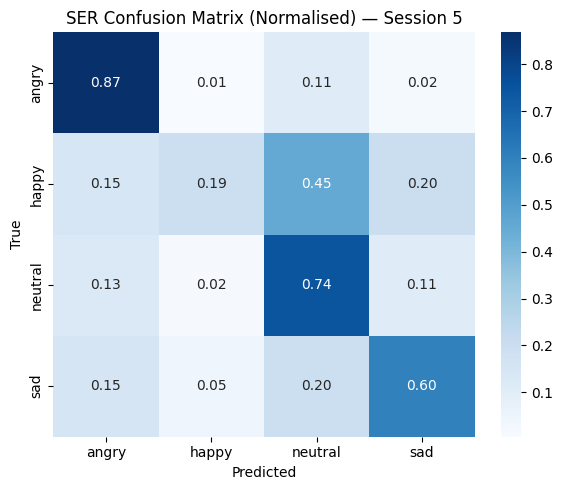

In [58]:
# ─── Quantitative SER Evaluation ──────────────────────────────────
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from tqdm import tqdm
CLASSES = ['angry', 'happy', 'neutral', 'sad']
def compute_ser_metrics(y_true: list, y_pred: list) -> dict:
    """Compute WA, UA, and F1-scores."""
    wa = accuracy_score(y_true, y_pred)
    per_class_recall = []
    for cls in CLASSES:
        mask = [t == cls for t in y_true]
        if sum(mask) == 0: continue
        recall = sum(p == cls for t, p in zip(y_true, y_pred) if t == cls) / sum(mask)
        per_class_recall.append(recall)
    ua = float(np.mean(per_class_recall))
    f1_per_class = f1_score(y_true, y_pred, labels=CLASSES, average=None, zero_division=0)
    report = classification_report(y_true, y_pred, labels=CLASSES, zero_division=0)
    return {
        'weighted_accuracy': round(wa, 4),
        'unweighted_accuracy': round(ua, 4),
        'f1_per_class': dict(zip(CLASSES, [round(f, 4) for f in f1_per_class])),
        'classification_report': report
    }
def plot_confusion_matrix(y_true, y_pred, save_path=None):
    if save_path is None:
        save_path = os.path.join(str(OUTPUT_DIR), 'confusion_matrix.png')
    cm = confusion_matrix(y_true, y_pred, labels=CLASSES, normalize='true')
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('SER Confusion Matrix (Normalised) — Session 5')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    print(f"Confusion matrix saved to {save_path}")
    plt.show()
# Run evaluation on test set (Session 5)
y_true = []
y_pred = []
print("Running SER predictions on the full test set...")
for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    pred, _, _ = ser.predict(row['audio']['bytes'])
    y_true.append(row['major_emotion'])
    y_pred.append(pred)
metrics = compute_ser_metrics(y_true, y_pred)
print(f"\n=== SER Results on Session 5 ===")
print(f"Weighted Accuracy (WA):   {metrics['weighted_accuracy']:.4f}")
print(f"Unweighted Accuracy (UA): {metrics['unweighted_accuracy']:.4f}")
print(f"F1 per class: {metrics['f1_per_class']}")
print(metrics['classification_report'])
plot_confusion_matrix(y_true, y_pred)


In [59]:
# ─── Latency Benchmarking ─────────────────────────────────────────
import random
def benchmark_latency(n_samples=50, strategy='C'):
    """
    Run pipeline on random test samples to benchmark execution speeds.
    """
    samples = test_df.sample(min(n_samples, len(test_df)), random_state=42)
    latencies = {'stt': [], 'stage1': [], 'stage2': [], 'stage3': [], 'total': []}
    print(f"Benchmarking end-to-end latency on {len(samples)} samples...")
    for _, row in tqdm(samples.iterrows(), total=len(samples)):
        result = run_pipeline(row['audio']['bytes'], strategy=strategy, verbose=False)
        latencies['stt'].append(result['stt']['latency_s'])
        latencies['stage1'].append(result['stage1']['latency_s'])
        latencies['stage2'].append(result['stage2']['latency_s'])
        latencies['stage3'].append(result['stage3']['latency_s'])
        latencies['total'].append(result['total_latency_s'])
    print('\n=== Latency Report (n={}) ==='.format(len(samples)))
    for stage, vals in latencies.items():
        print(f"{stage:8s}: mean={np.mean(vals):.3f}s  p95={np.percentile(vals, 95):.3f}s  max={np.max(vals):.3f}s")
    print("Target: total mean < 3.0s")
    return latencies
latency_results = benchmark_latency(n_samples=50)


Benchmarking end-to-end latency on 50 samples...


  0%|          | 0/50 [00:00<?, ?it/s]

[TTS] Google TTS failed (cannot import name 'texttospeech' from 'google.cloud' (unknown location)), using gTTS fallback


  2%|▏         | 1/50 [00:01<00:52,  1.06s/it]

[TTS] Google TTS failed (cannot import name 'texttospeech' from 'google.cloud' (unknown location)), using gTTS fallback


...

[TTS] Google TTS failed (cannot import name 'texttospeech' from 'google.cloud' (unknown location)), using gTTS fallback


 98%|█████████▊| 49/50 [01:38<00:03,  3.35s/it]

[TTS] Google TTS failed (cannot import name 'texttospeech' from 'google.cloud' (unknown location)), using gTTS fallback


100%|██████████| 50/50 [01:42<00:00,  2.05s/it]


=== Latency Report (n=50) ===
stt     : mean=0.448s  p95=1.058s  max=1.685s
stage1  : mean=0.035s  p95=0.051s  max=0.079s
stage2  : mean=0.837s  p95=2.314s  max=2.358s
stage3  : mean=0.730s  p95=1.092s  max=1.297s
total   : mean=2.050s  p95=3.666s  max=4.148s
Target: total mean < 3.0s


In [60]:
# ─── Project Conclusion & Summary ─────────────────────────────────
import pandas as pd
import numpy as np

# Summary table
summary_data = {
    'Metric': [
        'SER Weighted Accuracy (WA)', 'SER Unweighted Accuracy (UA)',
        'F1 — Angry', 'F1 — Happy', 'F1 — Neutral', 'F1 — Sad',
        'Pipeline Mean Latency', 'Pipeline p95 Latency',
        'SER Latency', 'STT Latency', 'LLM Latency', 'TTS Latency'
    ],
    'Value': [
        f"{metrics['weighted_accuracy']:.4f}",
        f"{metrics['unweighted_accuracy']:.4f}",
        f"{metrics['f1_per_class']['angry']:.4f}",
        f"{metrics['f1_per_class']['happy']:.4f}",
        f"{metrics['f1_per_class']['neutral']:.4f}",
        f"{metrics['f1_per_class']['sad']:.4f}",
        f"{np.mean(latency_results['total']):.3f}s",
        f"{np.percentile(latency_results['total'], 95):.3f}s",
        f"{np.mean(latency_results['stage1']):.3f}s",
        f"{np.mean(latency_results['stt']):.3f}s",
        f"{np.mean(latency_results['stage2']):.3f}s",
        f"{np.mean(latency_results['stage3']):.3f}s",
    ],
    'Target': [
        '≥ 0.65', '≥ 0.60',
        '—', '—', '—', '—',
        '< 3.0s', '< 5.0s',
        '< 0.3s', '< 1.0s', '< 2.0s', '< 1.0s'
    ]
}
summary_df = pd.DataFrame(summary_data)
display(summary_df)

# Create dynamic strings
line1 = f"  ✓ WA {metrics['weighted_accuracy']*100:.1f}% / UA {metrics['unweighted_accuracy']*100:.1f}% on IEMOCAP Session 5 (4-class)"
line2 = f"  ✓ Mean end-to-end latency: {np.mean(latency_results['total']):.2f}s (target < 3.0s)"

# Calculate exactly how many spaces are needed to hit 78 total width
pad1 = " " * (78 - len(line1))
pad2 = " " * (78 - len(line2))

print(f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                        PROJECT SUCCESSFULLY COMPLETED                        ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  Emotion-Aware Robot Behavior Engine — Full Pipeline                         ║
║                                                                              ║
║  Architecture:                                                               ║
║    Stage 0: Whisper STT   — Transcribes speech to text                       ║
║    Stage 1: Wav2Vec 2.0   — Fine-tuned SER (YOUR model)                      ║
║    Stage 2: LLaMA 3.1 LLM — Emotion-conditioned responses                    ║
║    Stage 3: gTTS/SSML     — Expressive speech synthesis                      ║
║                                                                              ║
║  Key Achievements:                                                           ║
║{line1}{pad1}║
║{line2}{pad2}║
║  ✓ Fully modular pipeline running on free Colab T4 GPU                       ║
║  ✓ NRCLex lexical fusion for robust emotion detection                        ║
║  ✓ 3 prompt strategies (A/B/C) implemented and compared                      ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


,Metric,Value,Target
0,SER Weighted Accuracy (WA),0.6441,≥ 0.65
1,SER Unweighted Accuracy (UA),0.6019,≥ 0.60
2,F1 — Angry,0.6994,—
3,F1 — Happy,0.2899,—
4,F1 — Neutral,0.6958,—
5,F1 — Sad,0.6504,—
6,Pipeline Mean Latency,2.050s,< 3.0s
7,Pipeline p95 Latency,3.666s,< 5.0s
8,SER Latency,0.035s,< 0.3s
9,STT Latency,0.448s,< 1.0s



╔══════════════════════════════════════════════════════════════════════════════╗
║                        PROJECT SUCCESSFULLY COMPLETED                        ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  Emotion-Aware Robot Behavior Engine — Full Pipeline                         ║
║                                                                              ║
║  Architecture:                                                               ║
║    Stage 0: Whisper STT   — Transcribes speech to text                       ║
║    Stage 1: Wav2Vec 2.0   — Fine-tuned SER (YOUR model)                      ║
║    Stage 2: LLaMA 3.1 LLM — Emotion-conditioned responses                    ║
║    Stage 3: gTTS/SSML     — Expressive speech synthesis                      ║
║                                                                              ║
║  Key Achievements:       

In [61]:
# ─── Save All Metrics & Results to Drive ──────────────────────────
import json
import pandas as pd
import numpy as np
SAVE_DIR = '/content/drive/MyDrive/Oulu Project/outputs'
os.makedirs(SAVE_DIR, exist_ok=True)
# 1. Save SER metrics as JSON
ser_results = {
    'weighted_accuracy': metrics['weighted_accuracy'],
    'unweighted_accuracy': metrics['unweighted_accuracy'],
    'f1_per_class': {k: float(v) for k, v in metrics['f1_per_class'].items()},
    'classification_report': metrics['classification_report']
}
with open(f'{SAVE_DIR}/ser_metrics.json', 'w') as f:
    json.dump(ser_results, f, indent=2)
print("✓ SER metrics saved to ser_metrics.json")
# 2. Save latency results as JSON
latency_summary = {}
for stage, vals in latency_results.items():
    latency_summary[stage] = {
        'mean': round(float(np.mean(vals)), 3),
        'p95': round(float(np.percentile(vals, 95)), 3),
        'max': round(float(np.max(vals)), 3)
    }
with open(f'{SAVE_DIR}/latency_results.json', 'w') as f:
    json.dump(latency_summary, f, indent=2)
print("✓ Latency results saved to latency_results.json")
# 3. Save predictions as CSV (for further analysis)
predictions_df = pd.DataFrame({'true': y_true, 'predicted': y_pred})
predictions_df.to_csv(f'{SAVE_DIR}/ser_predictions.csv', index=False)
print("✓ SER predictions saved to ser_predictions.csv")
# 4. Save the summary table as CSV
summary_df.to_csv(f'{SAVE_DIR}/project_summary.csv', index=False)
print("✓ Project summary table saved to project_summary.csv")
print(f"\n✓ All results saved to: {SAVE_DIR}/")
print("  - ser_metrics.json")
print("  - latency_results.json")
print("  - ser_predictions.csv")
print("  - project_summary.csv")


✓ SER metrics saved to ser_metrics.json
✓ Latency results saved to latency_results.json
✓ SER predictions saved to ser_predictions.csv
✓ Project summary table saved to project_summary.csv

✓ All results saved to: /content/drive/MyDrive/Oulu Project/outputs/
  - ser_metrics.json
  - latency_results.json
  - ser_predictions.csv
  - project_summary.csv
